# Data Preparation

Import necessary libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Read in the csv-file

In [24]:
charging_data = pd.read_csv("charging_sessions.csv")

## Data Dimensionality

Evaluate the dataset concerning dimensionality, data types and overall structure at first glance. 

In [25]:
charging_data.info(show_counts=True)
charging_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."


## Date Conversions

Every datetime entry is originally in UTC. To analyze the data in local time, we need to convert these values to the timezone of each charging site.

In [26]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    charging_data[data] = pd.to_datetime(charging_data[data])

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

charging_data = charging_data.apply(convert_to_local, axis=1)

charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0        66450 non-null  int64                              
 1   id                66450 non-null  object                             
 2   connectionTime    66450 non-null  datetime64[ns, America/Los_Angeles]
 3   disconnectTime    66450 non-null  datetime64[ns, America/Los_Angeles]
 4   doneChargingTime  62362 non-null  datetime64[ns, America/Los_Angeles]
 5   kWhDelivered      66450 non-null  float64                            
 6   sessionID         66450 non-null  object                             
 7   siteID            66450 non-null  int64                              
 8   spaceID           66450 non-null  object                             
 9   stationID         66450 non-null  object                     

## Duplicate Values

Check if "id" values are unique

In [27]:
duplicate_ids = charging_data["id"].duplicated(keep="first")
duplicate_ids = len(duplicate_ids[duplicate_ids == True])
duplicate_ids

1413

Hence, there are 1413 duplicate IDs. Further inspection of the duplicates is required before determining how to handle them.

In [28]:
# Collect all duplicated IDs
duplicated_ids = charging_data[charging_data["id"].duplicated()]
duplicated_ids = duplicated_ids["id"].unique()

# Define the subset of variables to inspect for duplicates. Exclude the unnamed index column.
subset_cols = charging_data.columns.difference(["Unnamed: 0"])

duplicates = charging_data[charging_data.duplicated(subset=subset_cols)]
len(duplicates)

1413

This shows that the entries with duplicate IDs also contain duplicate values for all other columns. Hence, the duplicates can be deleted without loss of information. 

In [29]:
charging_data = charging_data.drop_duplicates(subset=subset_cols, keep="first")
charging_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 65037 entries, 0 to 65036
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0        65037 non-null  int64                              
 1   id                65037 non-null  object                             
 2   connectionTime    65037 non-null  datetime64[ns, America/Los_Angeles]
 3   disconnectTime    65037 non-null  datetime64[ns, America/Los_Angeles]
 4   doneChargingTime  60950 non-null  datetime64[ns, America/Los_Angeles]
 5   kWhDelivered      65037 non-null  float64                            
 6   sessionID         65037 non-null  object                             
 7   siteID            65037 non-null  int64                              
 8   spaceID           65037 non-null  object                             
 9   stationID         65037 non-null  object                          

### Redundant features

We can drop the feature "Unnamed: 0". Furthermore the features "spaceID" and "stationID" hold the same information, as each spaceID belongs to exactly one stationID. Therefore we can also drop one of these features.

In [30]:
print("Unique values of spaceID: "+str(charging_data["spaceID"].nunique()))
print("Unique values of stationID: "+str(charging_data["stationID"].nunique()))
print((charging_data.groupby("spaceID")["stationID"].nunique() == 1).all())

charging_data = charging_data.drop(["Unnamed: 0", "stationID"], axis=1)
charging_data.info(show_counts=True)

Unique values of spaceID: 107
Unique values of stationID: 107
True
<class 'pandas.core.frame.DataFrame'>
Index: 65037 entries, 0 to 65036
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   id                65037 non-null  object                             
 1   connectionTime    65037 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime    65037 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime  60950 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered      65037 non-null  float64                            
 5   sessionID         65037 non-null  object                             
 6   siteID            65037 non-null  int64                              
 7   spaceID           65037 non-null  object                             
 8   timezone          65037 non-null  object                             
 9  

## Invalid Values

Possible invalid scenarios are:

1. connectionTime is after disconnectTime
2. connectionTime is after doneChargingTime
3. The same charging space (spaceID) has overlapping sessions
4. doneChargingTime is after disconnectTime
5. Sessions with zero delivered energy (no actual charging)

1. Scenario

In [31]:
scenario1 = charging_data["connectionTime"] > charging_data["disconnectTime"]
scenario1.value_counts()

False    65037
Name: count, dtype: int64

No invalid data found.

2. Scenario

In [32]:
scenario2 = charging_data["connectionTime"] > charging_data["doneChargingTime"]
scenario2.value_counts()

False    65010
True        27
Name: count, dtype: int64

Invalid data found. It is physically not possible that the "doneChargingTime" is before the "connectionTime" so we delete these entires.

In [33]:
charging_data.drop(charging_data[charging_data["connectionTime"] > charging_data["doneChargingTime"]].index, inplace = True)

3. Scenario

In [34]:
charging_data = charging_data.sort_values(["spaceID", "connectionTime"])
charging_data["next_connection"] = charging_data.groupby("spaceID")["connectionTime"].shift(-1)

charging_data["overlap"] = charging_data["disconnectTime"] > charging_data["next_connection"]
charging_data["overlap"].value_counts()



overlap
False    65009
True         1
Name: count, dtype: int64

Invalid data found. It is also physically not possible that the same Space has two overlapping sessions so we delete these entries as well as the new created column "overlap".

In [35]:
charging_data = charging_data.drop(charging_data[charging_data["overlap"]].index)
charging_data = charging_data.drop(columns=["overlap", "next_connection"])

charging_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65009 entries, 51322 to 48031
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   id                65009 non-null  object                             
 1   connectionTime    65009 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime    65009 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime  60922 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered      65009 non-null  float64                            
 5   sessionID         65009 non-null  object                             
 6   siteID            65009 non-null  int64                              
 7   spaceID           65009 non-null  object                             
 8   timezone          65009 non-null  object                             
 9   userID            47815 non-null  float64                     

4. scenario

In [36]:
scenario4 = charging_data["doneChargingTime"] > charging_data["disconnectTime"]
scenario4.value_counts()

False    60622
True      4387
Name: count, dtype: int64

Invalid data found. Since doneChargingTime cannot be after disconnectTime, we set doneChargingTime = disconnectTime for those cases.

In [37]:
charging_data.loc[scenario4, "doneChargingTime"] = charging_data.loc[scenario4, "disconnectTime"]

5. scenario

In [38]:
scenario5 = charging_data["kWhDelivered"] == 0
scenario5.value_counts()

kWhDelivered
False    65009
Name: count, dtype: int64

No invalid data found.

## Missing Values

Check for any missing values within the dataset

In [39]:
missing_values = charging_data.isnull().sum()
missing_values

id                      0
connectionTime          0
disconnectTime          0
doneChargingTime     4087
kWhDelivered            0
sessionID               0
siteID                  0
spaceID                 0
timezone                0
userID              17194
userInputs          17194
dtype: int64

Quick analysis of the missing values:
- **"doneChargingTime"**: Missing values are considered data irregularities and must be addressed to ensure high data quality
- **"userID"** and **"userInputs"**: Contain missing values as expected, since users are not required to register


## Handle doneChargingTime

To assess whether missing doneChargingTime values can be imputed, we analyze the relationship between charging duration and delivered energy.

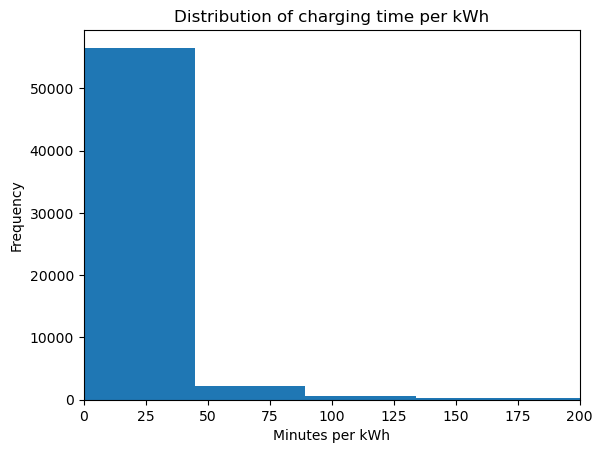

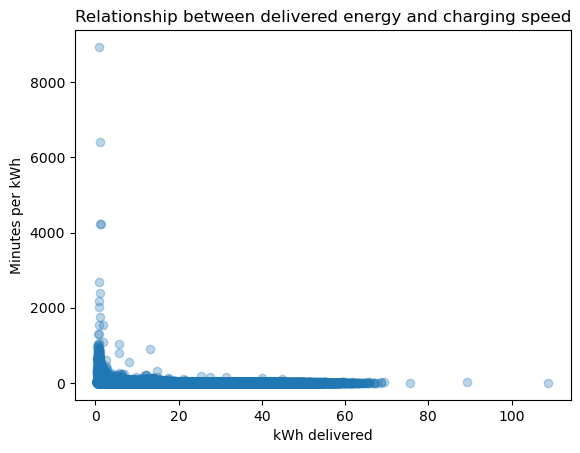

In [40]:
charging_data_regular_trips = charging_data[
    (charging_data['doneChargingTime'].notnull()) &
    (charging_data['kWhDelivered'] > 0)
].copy()

charging_data_regular_trips['chargingDuration'] = (
    charging_data_regular_trips['doneChargingTime'] -
    charging_data_regular_trips['connectionTime']
)

charging_data_regular_trips['minPerKWh'] = (
    charging_data_regular_trips['chargingDuration'].dt.total_seconds() / 60
) / charging_data_regular_trips['kWhDelivered']


plt.hist(charging_data_regular_trips['minPerKWh'], bins=200)
plt.xlim(0, 200)
plt.title("Distribution of charging time per kWh")
plt.xlabel("Minutes per kWh")
plt.ylabel("Frequency")
plt.show()

plt.scatter(
    charging_data_regular_trips['kWhDelivered'],
    charging_data_regular_trips['minPerKWh'],
    alpha=0.3
)
plt.title("Relationship between delivered energy and charging speed")
plt.xlabel("kWh delivered")
plt.ylabel("Minutes per kWh")
plt.show()


The variable doneChargingTime is essential for computing charging durations and utilization-related metrics. The exploratory analysis showed a strong heterogeneity and a nonlinear relationship between delivered energy and charging duration, particularly for low-energy sessions. Since charging duration depends on multiple unobserved factors such as vehicle characteristics, battery state-of-charge, nonlinear charging curves, and station-level power constraints, it cannot be reliably inferred from delivered energy alone. Consequently, imputing missing doneChargingTime values would require strong and unrealistic assumptions and risk introducing systematic bias. As the share of missing values is limited, sessions with missing doneChargingTime were excluded from all analyses requiring charging duration information.

In [41]:
charging_data = charging_data.dropna(subset=["doneChargingTime"])
charging_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60922 entries, 52871 to 48031
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   id                60922 non-null  object                             
 1   connectionTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime  60922 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered      60922 non-null  float64                            
 5   sessionID         60922 non-null  object                             
 6   siteID            60922 non-null  int64                              
 7   spaceID           60922 non-null  object                             
 8   timezone          60922 non-null  object                             
 9   userID            44637 non-null  float64                     

## Handle User Inputs

There are three possible scenarios for userInputs:
1. No user inputs
2. Exactly one user input
3. Several user inputs

Possible solutions for handling the userInputs:
- Leave the userInput attributes in the list column
- Create one column per userInputs attribute --> Each column contains a list of the input attribute values
- Create one column per userInputs attribute --> Each column contains only the last value for the input attribute

In [42]:
# Example of no userInputs 
print("No user inputs: \n", charging_data[charging_data["userInputs"].isnull()]["userInputs"].iloc[0])

# Example of one userInputs
print("Single user input: \n", charging_data["userInputs"].iloc[0])

# Example of multiple userInputs 
print("Multiple user inputs: \n", charging_data[charging_data["userID"] == 1117]["userInputs"].iloc[0])

No user inputs: 
 nan
Single user input: 
 nan
Multiple user inputs: 
 [{'WhPerMile': 400, 'kWhRequested': 8.0, 'milesRequested': 20, 'minutesAvailable': 291, 'modifiedAt': 'Fri, 07 Jun 2019 00:25:41 GMT', 'paymentRequired': True, 'requestedDeparture': 'Fri, 07 Jun 2019 05:16:30 GMT', 'userID': 1117}, {'WhPerMile': 400, 'kWhRequested': 8.0, 'milesRequested': 20, 'minutesAvailable': 120, 'modifiedAt': 'Fri, 07 Jun 2019 00:25:58 GMT', 'paymentRequired': True, 'requestedDeparture': 'Fri, 07 Jun 2019 02:25:30 GMT', 'userID': 1117}]


Now that we have analysed the user inputs, we leave them untouched and handle them task-specific.

### Save the data as a csv

In [43]:
charging_data.to_csv("../00_Productive_Data/charging_data_clean.csv")